# 05c · GSE65391 · RNA_array · where the 28 interferon response genes land

Reads `wgcna_input.rds`, `modules.rds`, `expression.rds` in `data/run_artifacts/GSE65391/`, and the gene lists in `genes/`. Writes a figure to `figures/GSE65391/`.

**Gene lists**
- `ifn-response-genes-28.txt`: the 28 interferon response genes. The same 28 genes are listed in Kim H et
  al. *J Interferon Cytokine Res* 2018;38:171-185 (Supplementary Table S1) and in de Jesus AA et al.
  *J Clin Invest* 2020;130:1669-1682 (Supplemental Figure 3B).
- The two papers define different 25-gene subsets:
  - Kim 2018 (`ifn-response-genes-25-kim2018.txt`): the 28 without EPSTI1, SIGLEC1 and SPATS2L, the three
    genes added from the literature.
  - de Jesus 2020 (`ifn-response-genes-25-stat1-only-dejesus2020.txt`): the 28 without CXCL10, GBP1 and
    SOCS1 (`ifn-response-genes-3-stat1-nfkb-dejesus2020.txt`), the genes with STAT1 and NF-kB binding sites.
- `nfkb-only-control-11-dejesus2020.txt`: 11 NF-kB target genes with no STAT1, STAT2 or TYK1 binding site
  (de Jesus 2020, Methods Step 2 and Supplemental Figure 5). They are the control.

The header of each gene file gives the sources and the differences between the two papers.

**What is reported for each gene.** Whether it is measured in this study, whether it is in the WGCNA
network, its module, and its kME with the interferon module: the Pearson correlation of the gene with the
module eigengene over the 157 first visits (Horvath S, Dong J. *PLoS Comput Biol* 2008;4:e1000117). No test is done; this is a description.

## Load the gene lists

In [1]:
source("../src/paths.R")
G <- "GSE65391"
irg28  <- read_gene_set("ifn-response-genes-28.txt")
kim25  <- read_gene_set("ifn-response-genes-25-kim2018.txt")
dj3    <- read_gene_set("ifn-response-genes-3-stat1-nfkb-dejesus2020.txt")
nfkb11 <- read_gene_set("nfkb-only-control-11-dejesus2020.txt")
g <- data.frame(set = rep(c("IRG-28", "NF-kB-11"), c(length(irg28), length(nfkb11))), gene = c(irg28, nfkb11))
g$kim2018_25 <- ifelse(g$set == "IRG-28", g$gene %in% kim25, NA)
g$dejesus2020_subscore <- ifelse(g$set == "IRG-28", ifelse(g$gene %in% dj3, "3 STAT1/NF-kB", "25 STAT1-only"), "")
table(g$set)


  IRG-28 NF-kB-11 
      28       11 

**Explanation**
- `source("../src/paths.R")` loads the locations and helpers (see notebook 00).
- `read_gene_set()` returns the gene symbols in a file of `genes/` (see notebook 00).
- `data.frame(set = ..., gene = ...)` makes one row per gene. `rep(c("IRG-28", "NF-kB-11"), c(28, 11))`
  repeats each label as many times as there are genes in its list.
- `kim2018_25` is TRUE for genes in Kim's 25-gene score. It is NA for the control genes.
- `dejesus2020_subscore` is "3 STAT1/NF-kB" for CXCL10, GBP1 and SOCS1, and "25 STAT1-only" for the other 25.
- `table(g$set)` counts the genes in each list: 28 and 11.

## Match the genes to this study

In [2]:
w <- readRDS(art(G, "wgcna_input.rds"))
m <- readRDS(art(G, "modules.rds"))
e <- readRDS(art(G, "expression.rds"))
g$measured   <- g$gene %in% rownames(e$E)
g$in_network <- g$gene %in% colnames(w$datExpr)
g$module     <- ifelse(g$in_network, unname(m$colors[g$gene]), NA)
c(samples_in_network = nrow(w$datExpr), genes_in_network = ncol(w$datExpr))

samples_in_network   genes_in_network 
               157               8825

**Explanation**
- `readRDS()` reads an R object saved by an earlier notebook. `art(G, file)` gives its path (see notebook 00).
  - `wgcna_input.rds` holds `datExpr`, the samples by genes matrix used for WGCNA.
  - `modules.rds` holds `colors`, the module of each gene, and `kME`, each gene's correlation with each module
    eigengene.
  - `expression.rds` holds `E`, all measured genes.
- `%in%` is TRUE where a gene is found in the other list.
- `measured`: the gene is in this study's expression table.
- `in_network`: the gene passed the filters of notebooks 02 and 04 and is in the WGCNA network.
- `module`: the gene's module; NA if it is not in the network. `unname()` drops the gene names that
  `m$colors[...]` carries.

## Find the interferon module

In [3]:
irg_modules <- sort(table(g$module[g$set == "IRG-28"]), decreasing = TRUE)
irg_modules
ifn_module <- names(irg_modules)[1]
ifn_module


pink grey 
  26    1 

[1] "pink"

**Explanation**
- `table()` counts how many of the 28 genes fall in each module; `sort(..., decreasing = TRUE)` puts the
  largest count first.
- The interferon module is defined as the module that holds the most of the 28 genes.
  `names(irg_modules)[1]` is its name.

## Correlation of each gene with the interferon module

In [4]:
net <- g$gene[g$in_network]
g$kME_ifn <- NA_real_
g$kME_ifn[g$in_network] <- round(m$kME[net, paste0("ME", ifn_module)], 2)
g

set,gene,kim2018_25,dejesus2020_subscore,measured,in_network,module,kME_ifn
<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<dbl>
IRG-28,CXCL10,TRUE,3 STAT1/NF-kB,TRUE,TRUE,pink,0.47
IRG-28,DDX60,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.84
IRG-28,EPSTI1,FALSE,25 STAT1-only,TRUE,TRUE,pink,0.87
IRG-28,GBP1,TRUE,3 STAT1/NF-kB,TRUE,TRUE,pink,0.83
IRG-28,HERC5,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.86
IRG-28,HERC6,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.84
IRG-28,IFI27,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.65
IRG-28,IFI44,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.85
IRG-28,IFI44L,TRUE,25 STAT1-only,TRUE,TRUE,pink,0.84


**Explanation**
- `net` holds the genes that are in the network. Genes outside the network have no kME.
- `NA_real_` fills the column with missing numbers first; the next line fills in the genes in the network.
- `m$kME[net, paste0("ME", ifn_module)]` takes each gene's correlation with the interferon module
  eigengene. `paste0("ME", ...)` builds the column name, for example `MEpink`.
- `round(..., 2)` keeps two decimals.

## Summary by gene list

In [5]:
summ <- do.call(rbind, lapply(split(g, g$set), function(d) data.frame(
  set = d$set[1], genes = nrow(d), measured = sum(d$measured), in_network = sum(d$in_network),
  in_ifn_module = sum(d$module == ifn_module, na.rm = TRUE),
  median_kME_ifn = median(d$kME_ifn, na.rm = TRUE))))
summ

,set,genes,measured,in_network,in_ifn_module,median_kME_ifn
,<chr>,<int>,<int>,<int>,<int>,<dbl>
IRG-28,IRG-28,28,28,27,26,0.84
NF-kB-11,NF-kB-11,11,11,5,0,0.32


**Explanation**
- `split(g, g$set)` divides the table into the 28 interferon response genes and the 11 control genes.
- `lapply(..., function(d) ...)` makes one summary row for each part; `do.call(rbind, ...)` stacks the rows.
- `sum()` of TRUE and FALSE values counts the TRUE values. `na.rm = TRUE` skips missing values.
- `median_kME_ifn` is the median correlation with the interferon module.

**Result.** The interferon module is pink. 26 of the 28 genes are in it, with kME 0.47 (CXCL10) to
0.92 (OASL); median 0.84. The two others: IFI6 is in the network but grey (kME with pink 0.14), and
SIGLEC1 is below the expression threshold of notebook 02, so it is not in the network. Of the 3
STAT1/NF-kB genes, CXCL10 (0.47) and SOCS1 (0.62) have the lowest kME in pink.

Control: none of the 11 NF-kB genes is in pink. Six (AICDA, EBI3, IFNG, MSR1, SELP, XIAP) are below
the expression threshold; the other five are in turquoise, midnightblue, blue and salmon, with kME with
pink 0.14 to 0.40.

## Figure

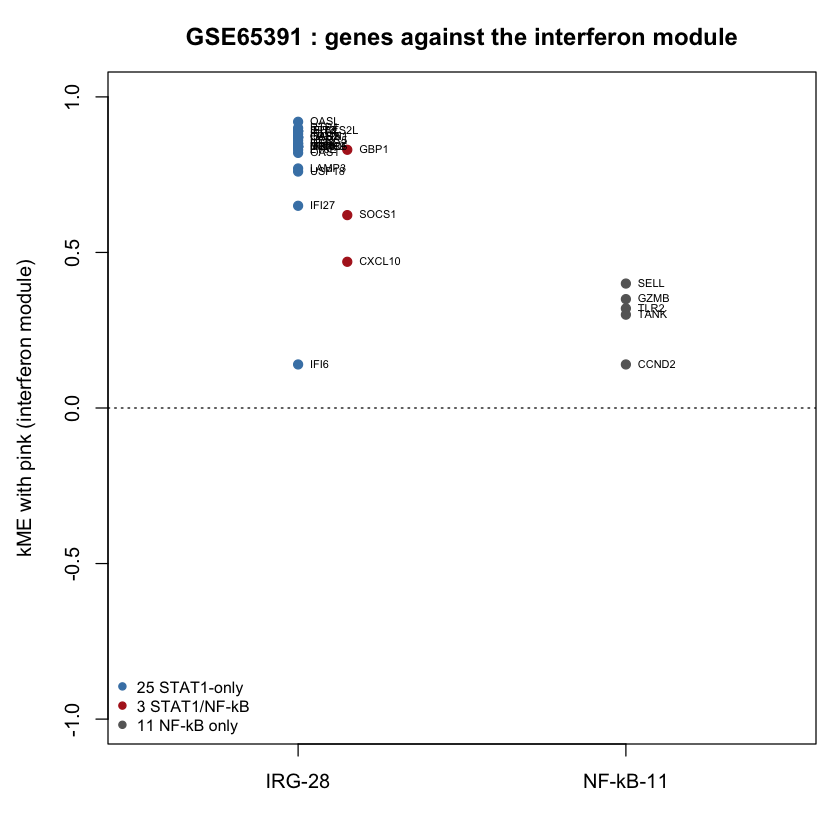

In [6]:
figure <- function() {
  d <- g[g$in_network, ]
  d$x <- ifelse(d$set == "IRG-28", 1, 2) + ifelse(d$dejesus2020_subscore == "3 STAT1/NF-kB", 0.15, 0)
  par(mar = c(4, 4.5, 3, 1))
  plot(d$x, d$kME_ifn, xlim = c(0.5, 2.5), ylim = c(-1, 1), xaxt = "n", pch = 19,
       col = ifelse(d$set == "NF-kB-11", "grey40", ifelse(d$dejesus2020_subscore == "3 STAT1/NF-kB", "firebrick", "steelblue")),
       xlab = "", ylab = paste0("kME with ", ifn_module, " (interferon module)"),
       main = paste(G, ": genes against the interferon module"))
  axis(1, at = 1:2, labels = c("IRG-28", "NF-kB-11")); abline(h = 0, lty = 3)
  text(d$x, d$kME_ifn, d$gene, pos = 4, cex = 0.55)
  legend("bottomleft", c("25 STAT1-only", "3 STAT1/NF-kB", "11 NF-kB only"), pch = 19,
         col = c("steelblue", "firebrick", "grey40"), bty = "n", cex = 0.8)
}
for (device in c("inline", "png")) {
  if (device == "png") png(fig(G, "05c_interferon_genes.png"), width = 7, height = 7, units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `figure()` draws one point per gene in the network: its kME with the interferon module (vertical axis),
  the 28 interferon response genes on the left and the 11 control genes on the right.
- Colours: blue for the 25 STAT1-only genes, red for CXCL10, GBP1 and SOCS1, grey for the controls.
- The loop draws the figure twice: once in the notebook, and once into a 300 dpi PNG in `figures/`
  (notebook 07 explains this loop).